In [26]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax as dfrx
import equinox as eqx
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys
from scipy import stats
from cld4py import assign_letters

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_nonessential_all_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True

In [27]:
save_dir_base = '../../../results/predictions/exercise/'

resist_color = '#6b8ba4'
run_color = '#fc5a50'
plot_color = '#175449'

model = "MM_nonessential_all"
save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

### Explore Francis et al predictions

In [28]:
data_dir = './20250525_Francis_et_al'
col_names = ['time (s)', 'calcium (uM)', 'ATP hydrolysis rate (uM/s)']

resistance_data = pd.read_csv(os.path.join(data_dir, 'resistance_data.txt'), sep=' ',
                              header=0, names=col_names)

running_data = pd.read_csv(os.path.join(data_dir, 'running_data.txt'), sep=' ',
                            header=0, names=col_names)

Plots of the stimuli

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/355721445.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_calcium.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/355721445.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_calcium_inlay.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/355721445.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_ATP_flux.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/355721445.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrec

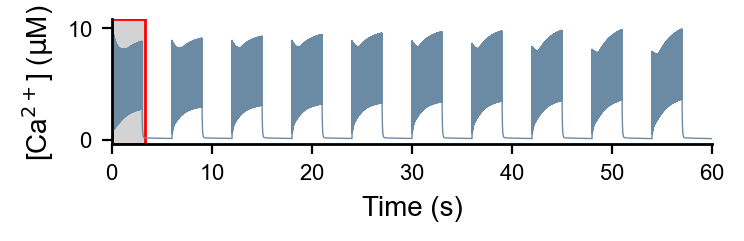

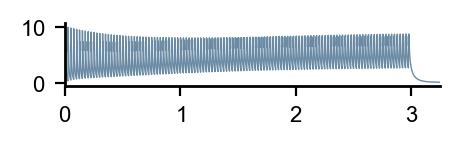

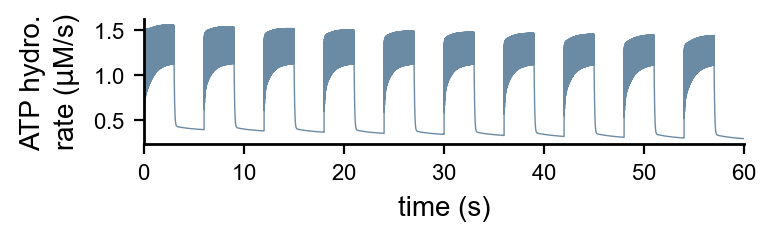

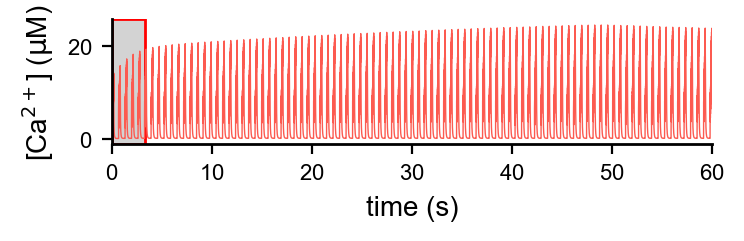

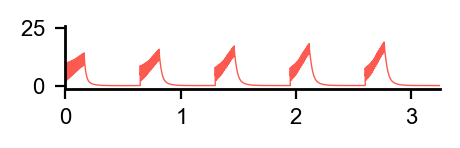

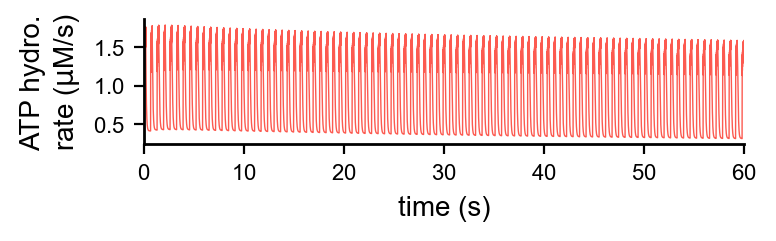

In [29]:
width= 1.5
height= 1.25

fig, ax = get_sized_fig_ax(2*width, height/2)
ax.plot(resistance_data['time (s)'], resistance_data['calcium (uM)'], 
        label='Calcium flux', linewidth=0.5, color=resist_color)
ax.set_xlim(0, 60)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=10)
ax.axvspan(0, 3.25, facecolor='lightgray', edgecolor='r', linewidth=1)
fig.savefig(save_dir + 'resistance_calcium.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(1.25*width, height/4)
ax.plot(resistance_data['time (s)'], resistance_data['calcium (uM)'], 
        label='Calcium flux', linewidth=0.5, color=resist_color)
ax.set_xlim(0, 3.25)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
fig.savefig(save_dir + 'resistance_calcium_inlay.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/2)
ax.plot(resistance_data['time (s)'], resistance_data['ATP hydrolysis rate (uM/s)']/1000, 
        linewidth=0.5, color=resist_color)
ax.set_xlim(0, 60)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel('ATP hydro.\nrate ' +r'($\mu$M/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_ATP_flux.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/2)
ax.plot(running_data['time (s)'], running_data['calcium (uM)'], 
        label='Calcium flux', linewidth=0.5, color=run_color)
ax.set_xlim(0, 60)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=10)
ax.axvspan(0, 3.25, facecolor='lightgray', edgecolor='r', linewidth=1)
fig.savefig(save_dir + 'running_calcium.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(1.25*width, height/4)
ax.plot(running_data['time (s)'], running_data['calcium (uM)'], 
        label='Calcium flux', linewidth=0.5, color=run_color)
ax.set_xlim(0, 3.25)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
fig.savefig(save_dir + 'running_calcium_inlay.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/2)
ax.plot(running_data['time (s)'], running_data['ATP hydrolysis rate (uM/s)']/1000, 
        linewidth=0.5, color=run_color)
ax.set_xlim(0, 60)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel('ATP hydro.\nrate ' +r'($\mu$M/s)', fontsize=10)
fig.savefig(save_dir + 'running_ATP_flux.pdf', bbox_inches='tight', 
            transparent=True)

Set up: Model

In [30]:
sampler = "Pathfinder"

model = "MM_nonessential_all"
model_info_file = '../models/MM_nonessential_all.json'

data_dir = '../../../results/param_est/kinase_KO/std_dcr/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength
k_gly_idx = list(metab_params["metab_params_basal"].keys()).index("kGly")
k_hydro_idx = list(metab_params["metab_params_basal"].keys()).index("kHydro")

# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

ca_index = list(model_info["init_conds"].keys()).index("Ca")
total_AMPKAR = model_info["init_conds"]["AMPKAR"]

MM_non_all = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
rhs = dfrx.ODETerm(MM_non_all.prescribe_Ca_ATP_flux)

def dynamic_stim(params, rhs, y0, times, Ca_func, kHydro_func, Ca_basal, kHydro_basal,
        tmax_init=1e3, rtol=1e-6, atol=1e-6, pcoeff=0.3, 
        icoeff=0.4, dcoeff=0.0, dt0=1e-10, solver = dfrx.Kvaerno5()):
    """ Function to solve the ODE with dynamic stimuli. The time-dependent RHS func expercts functions for the Ca2+ concentration and kHydro rate as the final two params in the params list (calcium first, then kHydro)."""
    
    # solver details
    stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
    t0 = 0.0
    t1 = times[-1]
    saveat=dfrx.SaveAt(ts=times)
    # saveat=dfrx.SaveAt(t0=True, t1=True, steps=True)
    # max_steps=int(3)

    # first equilibrate the system with basal conditions
    ca_basal_func = lambda t: Ca_basal
    kHydro_basal_func = lambda t: kHydro_basal

    basal_params = list(params.copy())
    basal_params.append(ca_basal_func)
    basal_params.append(kHydro_basal_func)

    sol = dfrx.diffeqsolve(
        rhs, solver, 
        t0, tmax_init, dt0, 
        y0, 
        args=basal_params,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        throw=True)
    
    # now apply the dynamic stimuli
    stim_params = list(params.copy())
    stim_params.append(Ca_func)
    stim_params.append(kHydro_func)

    # run the simulation
    sol_stressed = dfrx.diffeqsolve(
        rhs, solver, 
        t0, t1, dt0, 
        sol.ys, # use basal SS at IC
        args=stim_params, 
        saveat=saveat,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        max_steps=1000000,
        throw=False)
    
    return sol_stressed

@jax.jit
def compute_pAMPK_act(param, ca_interp, atp_interp, times):

    ca_t = lambda t: ca_interp.evaluate(t)
    atp_t = lambda t: atp_interp.evaluate(t)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, times, ca_t, atp_t, 0.0, 0.0,
                   atol=1e-6, rtol=1e-6)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(jnp.squeeze(jnp.array(sol.ys)), param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=sol.ts)
    # return pAMPK_activity_AUC, pAMPK_activity, sol
    return pAMPK_activity, sol.ts, sol.ys


def compute_pAMPK_activity(sol, param, pampk_idxs=np.array([10, 15, 16]), amp_pampk_idx=14):
    return sol[pampk_idxs, :].sum(axis=0)*param[12] + sol[amp_pampk_idx, :]*param[12]*param[24]

Set up simulator funcs

Will interpolate the model inputs in order to eval when the model needs

Will use the Diffrax cubic spline interpolator with Hermite polynomial (https://docs.kidger.site/diffrax/api/interpolation/)

In [31]:
tfine = np.linspace(resistance_data['time (s)'][0], resistance_data['time (s)'][10], 30)
# Resistantance data
coeffs_res_ca = dfrx.backward_hermite_coefficients(resistance_data['time (s)'].to_numpy(), 
                                                   resistance_data['calcium (uM)'].to_numpy())
interp_res_ca = dfrx.CubicInterpolation(resistance_data['time (s)'].to_numpy(), coeffs_res_ca)

coeffs_res_atp = dfrx.backward_hermite_coefficients(resistance_data['time (s)'].to_numpy(), 
                                                    resistance_data['ATP hydrolysis rate (uM/s)'].to_numpy()/1000)
interp_res_atp = dfrx.CubicInterpolation(resistance_data['time (s)'].to_numpy(), coeffs_res_atp)

# Running data
coeffs_run_ca = dfrx.backward_hermite_coefficients(running_data['time (s)'].to_numpy(), 
                                                   running_data['calcium (uM)'].to_numpy())
interp_run_ca = dfrx.CubicInterpolation(running_data['time (s)'].to_numpy(), coeffs_run_ca)

coeffs_run_atp = dfrx.backward_hermite_coefficients(running_data['time (s)'].to_numpy(), 
                                                    running_data['ATP hydrolysis rate (uM/s)'].to_numpy()/1000)
interp_run_atp = dfrx.CubicInterpolation(running_data['time (s)'].to_numpy(), coeffs_run_atp)


Run simulations

In [32]:
# random sample from the posterior
nsamples=50
params = get_param_subsample(param_names, idata_cyto, nsamples) # one param for now, then draw a random subset
times = np.linspace(0, 60, 10000)

# resistance
res_sims = []
for i in range(nsamples):
    res_sim = compute_pAMPK_act(params[i], interp_res_ca, interp_res_atp, times)
    res_sims.append(res_sim)

In [33]:
# running
run_sims = []
for i in range(nsamples):
    run_sim = compute_pAMPK_act(params[i], interp_run_ca, interp_run_atp, times)
    run_sims.append(run_sim)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/1134236709.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_AMPK_act.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/1134236709.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'running_AMPK_act.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figur

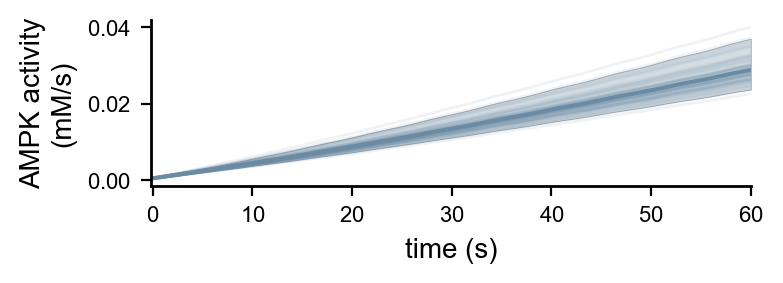

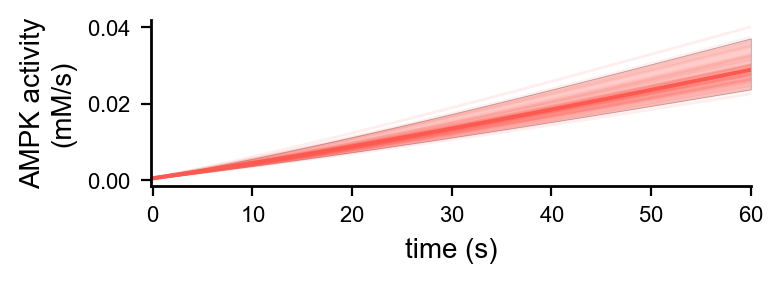

In [34]:
fig, ax = get_sized_fig_ax(2*width, height/1.5)
sims = []
times = []
for i in range(nsamples):
    sim = res_sims[i][0]
    sims.append(sim)
    t_sim = res_sims[i][1]
    times.append(t_sim)
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=resist_color, alpha=0.1)

ax.plot(t_sim, np.array(sims).mean(axis=0), linewidth=1.5, color=resist_color,)
ax.fill_between(t_sim, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=resist_color, alpha=0.3, edgecolor='k')

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.2, 60)
ax.set_ylabel('AMPK activity\n'+r'(mM/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_AMPK_act.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/1.5)
sims = []
times = []
for i in range(nsamples):
    sim = run_sims[i][0]
    sims.append(sim)
    t_sim = run_sims[i][1]
    times.append(t_sim)
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=run_color, alpha=0.1)

ax.plot(t_sim, np.array(sims).mean(axis=0), linewidth=1.5, color=run_color,)
ax.fill_between(t_sim, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=run_color, alpha=0.3, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.2, 60)
ax.set_ylabel('AMPK activity\n'+r'(mM/s)', fontsize=10)
fig.savefig(save_dir + 'running_AMPK_act.pdf', bbox_inches='tight', 
            transparent=True)

Bar plot of final predictions

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3847477354.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat_long = dat_df.applymap(lambda x: float(x[0])).reset_index().melt(id_vars='index',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3847477354.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dat_long, ax=ax, x='condition', y='AMPK activity',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3847477354.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'exercise_AMPK_activity_barplot.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes t

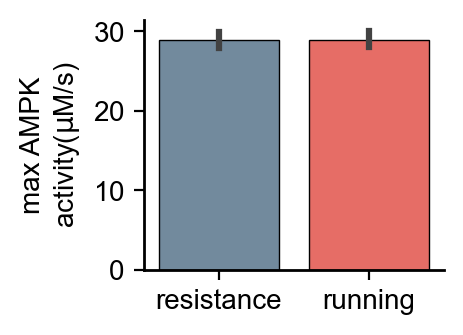

In [35]:
res_final_act = [res_sims[i][0][np.where(res_sims[i][1] == 60)[0]]*1000 for i in range(nsamples)]
run_final_act = [run_sims[i][0][np.where(run_sims[i][1] == 60)[0]]*1000 for i in range(nsamples)]

dat_df = pd.DataFrame({'resistance': res_final_act, 'running': run_final_act})
dat_long = dat_df.applymap(lambda x: float(x[0])).reset_index().melt(id_vars='index', 
                var_name='condition', value_name='AMPK activity').drop('index', axis=1)

fig, ax = get_sized_fig_ax(width, height)
sns.barplot(data=dat_long, ax=ax, x='condition', y='AMPK activity',
            palette=[resist_color, run_color],
            linewidth=0.5, edgecolor='black')
ax.set_ylabel('max AMPK\nactivity' + r'($\mu$M/s)', fontsize=10)
ax.set_xlabel('')
fig.savefig(save_dir + 'exercise_AMPK_activity_barplot.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/2679816762.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_AMP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/2679816762.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'running_AMP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/2679816762.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AMP_ylab.pdf', bbox_inches='tight',


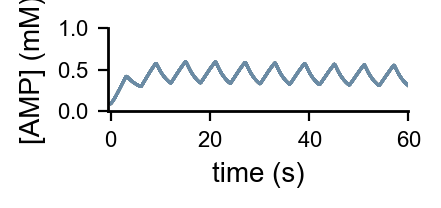

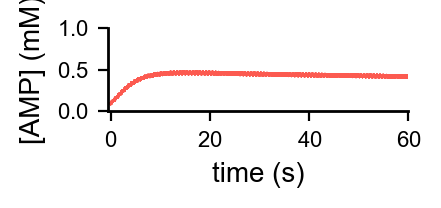

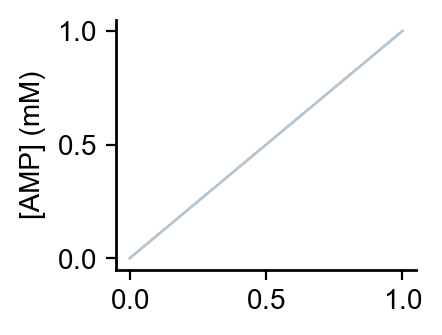

In [36]:
fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = res_sims[i][2][0]
    t_sim = res_sims[i][1]
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=resist_color, alpha=0.5)

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
ax.set_xlim(-0.5, 60)
ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'resistance_AMP.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = run_sims[i][2][0]
    t_sim = run_sims[i][1]
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=run_color, alpha=0.5)
# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
ax.set_xlim(-0.5, 60)
ax.set_yticks([0, 0.5, 1.0])
fig.savefig(save_dir + 'running_AMP.pdf', bbox_inches='tight', 
            transparent=True)

# dummy plot with ylabel
fig, ax = get_sized_fig_ax(width, height)
ax.plot([0, 1], [0, 1], linewidth=1.0, color=resist_color, alpha=0.5)
ax.set_ylabel('[AMP] (mM)', fontsize=10)
fig.savefig(save_dir + 'AMP_ylab.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3402200866.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_ATP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3402200866.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'running_ATP.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3402200866.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'ATP_ylab.pdf', bbox_inches='tight',


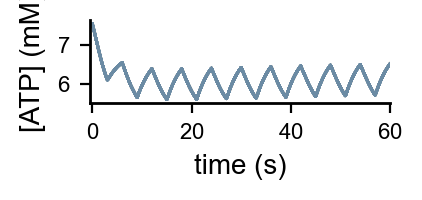

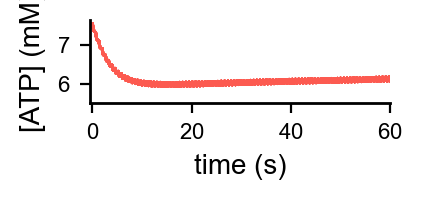

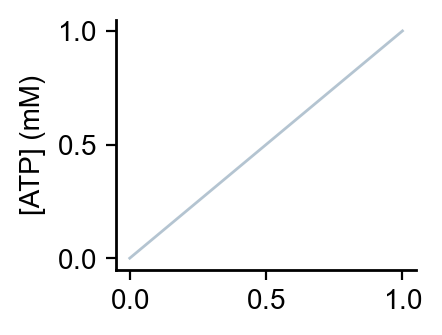

In [37]:
fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = res_sims[i][2][2]
    t_sim = res_sims[i][1]
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=resist_color, alpha=0.5)

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
ax.set_xlim(-0.5, 60)
fig.savefig(save_dir + 'resistance_ATP.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = run_sims[i][2][2]
    t_sim = run_sims[i][1]
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=run_color, alpha=0.5)
# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
ax.set_xlim(-0.5, 60)
fig.savefig(save_dir + 'running_ATP.pdf', bbox_inches='tight', 
            transparent=True)

# dummy plot with ylabel
fig, ax = get_sized_fig_ax(width, height)
ax.plot([0, 1], [0, 1], linewidth=1.0, color=resist_color, alpha=0.5)
ax.set_ylabel('[ATP] (mM)', fontsize=10)
fig.savefig(save_dir + 'ATP_ylab.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/1196294874.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_CaMKK2.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/1196294874.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'running_CaMKK2.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/1196294874.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'CaMKK2_ylab.pdf', bbox_inches='tight',


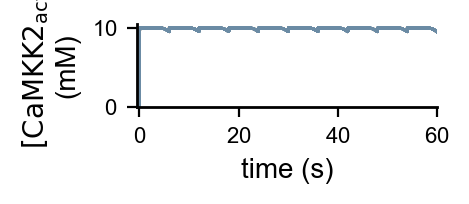

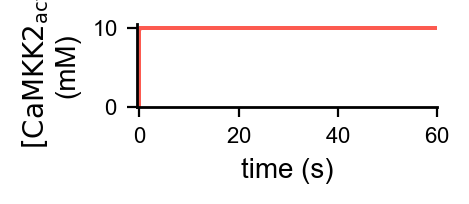

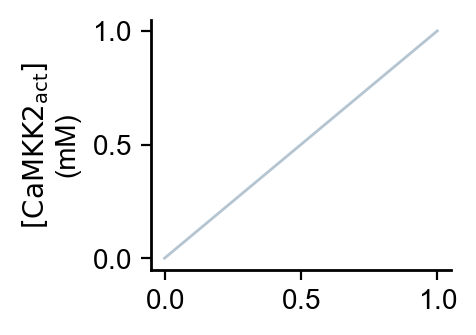

In [38]:
fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = res_sims[i][2][8]
    t_sim = res_sims[i][1]
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=resist_color, alpha=0.5)

# ax.set_xlim(0, 10)
ylim = ax.get_ylim()
ax.set_ylim(0, ylim[1])
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.5, 60)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
fig.savefig(save_dir + 'resistance_CaMKK2.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(width, height/3)
for i in range(nsamples):
    sim = run_sims[i][2][8]
    t_sim = run_sims[i][1]
    # plot the calcium flux
    ax.plot(t_sim, sim, linewidth=1.0, color=run_color, alpha=0.5)
# ax.set_xlim(0, 10)
ax.set_ylim(0, ylim[1])
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.5, 60)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
fig.savefig(save_dir + 'running_CaMKK2.pdf', bbox_inches='tight', 
            transparent=True)

# dummy plot with ylabel
fig, ax = get_sized_fig_ax(width, height)
ax.plot([0, 1], [0, 1], linewidth=1.0, color=resist_color, alpha=0.5)
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
fig.savefig(save_dir + 'CaMKK2_ylab.pdf', bbox_inches='tight',
            transparent=True)

### Upstream kinase knockouts

In [39]:
times = np.linspace(0, 60, 10000)

@jax.jit
def compute_pAMPK_act_LKB1_KO(param, ca_interp, atp_interp, times):

    ca_t = lambda t: ca_interp.evaluate(t)
    atp_t = lambda t: atp_interp.evaluate(t)

    lkb1_tot_idx = 16
    lkb1_phos_idx = 8
    # print(param)
    # set the LKB1 total concentration to 0
    param = param.at[lkb1_tot_idx].set(0.0)
    param = param.at[lkb1_phos_idx].set(0.0)
    # param[lkb1_tot_idx] = 0.0
    # print(param)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, times, ca_t, atp_t, 0.0, 0.0,
                   atol=1e-6, rtol=1e-6)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(jnp.squeeze(jnp.array(sol.ys)), param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=sol.ts)
    # return pAMPK_activity_AUC, pAMPK_activity, sol
    return pAMPK_activity, sol.ts, sol.ys

@jax.jit
def compute_pAMPK_act_CaMKK2_KO(param, ca_interp, atp_interp, times):

    ca_t = lambda t: ca_interp.evaluate(t)
    atp_t = lambda t: atp_interp.evaluate(t)

    CaMKK2_idx = 7
    # set the LKB1 total concentration to 0
    y0_local = y0.copy()
    y0_local[CaMKK2_idx] = 0.0
    # y0 = y0.at[CaMKK2_idx].set(0.0)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0_local, times, ca_t, atp_t, 0.0, 0.0,
                   atol=1e-6, rtol=1e-6)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(jnp.squeeze(jnp.array(sol.ys)), param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=sol.ts)
    # return pAMPK_activity_AUC, pAMPK_activity, sol
    return pAMPK_activity, sol.ts, sol.ys

In [40]:
# resistance
res_sims_LKB1_KO = []
for i in range(nsamples):
    res_sim = compute_pAMPK_act_LKB1_KO(params[i], interp_res_ca, interp_res_atp, times)
    res_sims_LKB1_KO.append(res_sim)

res_sims_CaMKK2_KO = []
for i in range(nsamples):
    res_sim = compute_pAMPK_act_CaMKK2_KO(params[i], interp_res_ca, interp_res_atp, times)
    res_sims_CaMKK2_KO.append(res_sim)

# running
run_sims_LKB1_KO = []
for i in range(nsamples):
    run_sim = compute_pAMPK_act_LKB1_KO(params[i], interp_run_ca, interp_run_atp, times)
    run_sims_LKB1_KO.append(run_sim)

run_sims_CaMKK2_KO = []
for i in range(nsamples):
    run_sim = compute_pAMPK_act_CaMKK2_KO(params[i], interp_run_ca, interp_run_atp, times)
    run_sims_CaMKK2_KO.append(run_sim)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3505122537.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_AMPK_act_LKB1_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3505122537.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'resistance_AMPK_act_CaMKK2_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3505122537.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'running_AMPK_act_LKB1_KO.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3505122537.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so re

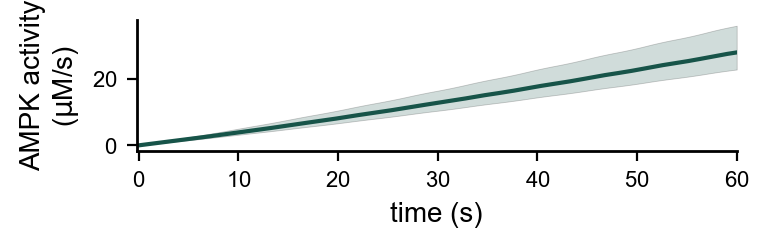

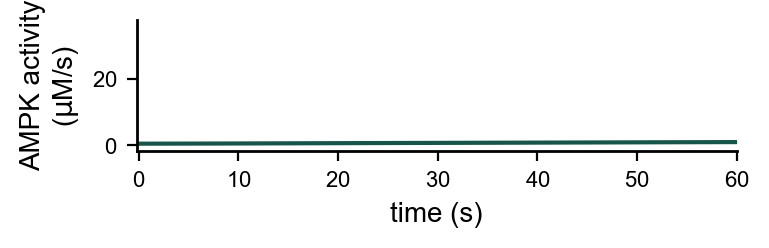

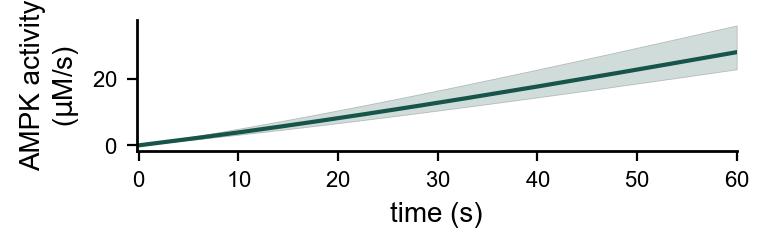

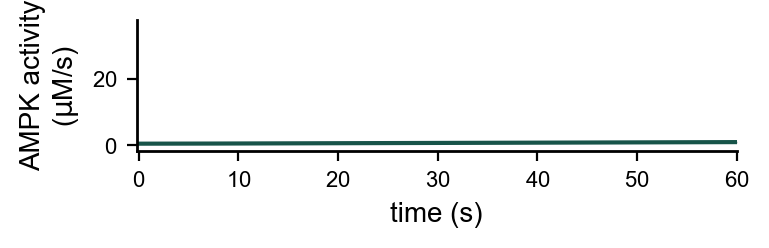

In [41]:
fig, ax = get_sized_fig_ax(2*width, height/1.9)
sims = []
times = []
for i in range(nsamples):
    sim = res_sims_LKB1_KO[i][0]*1000
    sims.append(sim)
    t_sim = res_sims_LKB1_KO[i][1]
    times.append(t_sim)
    # plot the calcium flux
    # ax.plot(t_sim, sim, linewidth=1.0, color=plot_color, alpha=0.5)

ax.plot(t_sim, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(t_sim, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.2, edgecolor='k')

# ax.set_xlim(0, 10)
# ax.set_ylim(ylim)
ylim = ax.get_ylim()
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.2, 60)
ax.set_ylabel('AMPK activity\n'+r'($\mu$M/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_AMPK_act_LKB1_KO.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/1.9)
sims = []
times = []
for i in range(nsamples):
    sim = res_sims_CaMKK2_KO[i][0]*1000
    sims.append(sim)
    t_sim = res_sims_CaMKK2_KO[i][1]
    times.append(t_sim)
    # plot the calcium flux
    # ax.plot(t_sim, sim, linewidth=1.0, color=plot_color, alpha=0.5)

ax.plot(t_sim, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(t_sim, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.2, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.2, 60)
ax.set_ylabel('AMPK activity\n'+r'($\mu$M/s)', fontsize=10)
fig.savefig(save_dir + 'resistance_AMPK_act_CaMKK2_KO.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/1.9)
sims = []
times = []
for i in range(nsamples):
    sim = run_sims_LKB1_KO[i][0]*1000
    sims.append(sim)
    t_sim = run_sims_LKB1_KO[i][1]
    times.append(t_sim)
    # plot the calcium flux
    # ax.plot(t_sim, sim, linewidth=1.0, color=plot_color, alpha=0.5)

ax.plot(t_sim, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(t_sim, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.2, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.2, 60)
ax.set_ylabel('AMPK activity\n'+r'($\mu$M/s)', fontsize=10)
fig.savefig(save_dir + 'running_AMPK_act_LKB1_KO.pdf', bbox_inches='tight', 
            transparent=True)

fig, ax = get_sized_fig_ax(2*width, height/1.9)
sims = []
times = []
for i in range(nsamples):
    sim = run_sims_CaMKK2_KO[i][0]*1000
    sims.append(sim)
    t_sim = run_sims_CaMKK2_KO[i][1]
    times.append(t_sim)
    # plot the calcium flux
    # ax.plot(t_sim, sim, linewidth=1.0, color=plot_color, alpha=0.5)

ax.plot(t_sim, np.array(sims).mean(axis=0), linewidth=1.5, color=plot_color,)
ax.fill_between(t_sim, np.percentile(np.array(sims), 2.5, axis=0), 
                       np.percentile(np.array(sims), 97.5, axis=0), 
                       color=plot_color, alpha=0.2, edgecolor='k')

# ax.set_xlim(0, 10)
ax.set_ylim(ylim)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlabel('time (s)', fontsize=10)
ax.set_xlim(-0.2, 60)
ax.set_ylabel('AMPK activity\n'+r'($\mu$M/s)', fontsize=10)
fig.savefig(save_dir + 'running_AMPK_act_CaMKK2_KO.pdf', bbox_inches='tight', 
            transparent=True)

In [42]:
res_final_act = [res_sims[i][0][np.where(res_sims[i][1] == 60)[0]] for i in range(nsamples)]
run_final_act = [run_sims[i][0][np.where(run_sims[i][1] == 60)[0]] for i in range(nsamples)]
res_final_act_LKB1_KO = [res_sims_LKB1_KO[i][0][np.where(res_sims_LKB1_KO[i][1] == 60)[0]] for i in range(nsamples)]
run_final_act_LKB1_KO = [run_sims_LKB1_KO[i][0][np.where(run_sims_LKB1_KO[i][1] == 60)[0]] for i in range(nsamples)]
res_final_act_CaMKK2_KO = [res_sims_CaMKK2_KO[i][0][np.where(res_sims_CaMKK2_KO[i][1] == 60)[0]] for i in range(nsamples)]
run_final_act_CaMKK2_KO = [run_sims_CaMKK2_KO[i][0][np.where(run_sims_CaMKK2_KO[i][1] == 60)[0]] for i in range(nsamples)]

resist_df = pd.DataFrame({'WT':res_final_act, 'CaMKK2 KO': res_final_act_CaMKK2_KO})
run_df = pd.DataFrame({'WT':run_final_act, 'CaMKK2 KO': run_final_act_CaMKK2_KO})

resist_df_long = resist_df.applymap(lambda x: float(x[0])).reset_index().melt(id_vars='index', 
                var_name='condition', value_name='AMPK activity').drop('index', axis=1)
resist_df_long['exercise'] = 'resistance'

run_df_long = run_df.applymap(lambda x: float(x[0])).reset_index().melt(id_vars='index',
                var_name='condition', value_name='AMPK activity').drop('index', axis=1)
run_df_long['exercise'] = 'running'
resist_df_long['exercise'] = resist_df_long['exercise'].astype('category')
run_df_long['exercise'] = run_df_long['exercise'].astype('category')

df_long = pd.concat([resist_df_long, run_df_long], axis=0)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3536395480.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  resist_df_long = resist_df.applymap(lambda x: float(x[0])).reset_index().melt(id_vars='index',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/3536395480.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  run_df_long = run_df.applymap(lambda x: float(x[0])).reset_index().melt(id_vars='index',


In [45]:
# Get all unique groups
groups = df_long.groupby(['condition', 'exercise'])['AMPK activity'].apply(list)
print(len(groups))

# Perform one-way ANOVA across all groups
anova_result = stats.f_oneway(*groups)
anova_result

# compute n_comparison pairs to apply Bonferroni correction
n_comparisons = len(groups) * (len(groups) - 1) / 2
alpha_corrected = 0.05 / n_comparisons

comparisons_df = pd.DataFrame()

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1, group2 = groups.keys()[i], groups.keys()[j]
      
        t_stat, p_value = stats.ttest_ind(groups[group1], groups[group2])
        comparisons_df = pd.concat([comparisons_df, 
                                    pd.DataFrame({'group1':group1[1] + '-' + group1[0],
                                                  'group2':group2[1] + '-' + group2[0],
                                                  'pvalue':p_value},index=[0])])
    


order = [ 'resistance-WT', 'running-WT', 'resistance-CaMKK2 KO', 'running-CaMKK2 KO']

# assign cld letters
cld_results = assign_letters(comparisons_df, G1='group1', G2='group2', P='pvalue',
                             order=order, alpha=alpha_corrected)

# now process the cld_results so that it is suitable for plotting in the hue grouped barplot
cld_df = cld_results['Letters'].reset_index()
cld_df.columns = ['Group', 'Letters']
cld_df['exercise'] = cld_df['Group'].apply(lambda x: x.split('-')[0])
cld_df['condition'] = cld_df['Group'].apply(lambda x: x.split('-')[1])
cld_df = cld_df.drop(columns=['Group'])
cld_df['Letters'] = cld_df['Letters'].str.upper()
print(cld_df)

4
  Letters    exercise  condition
0       A  resistance         WT
1       A     running         WT
2       B  resistance  CaMKK2 KO
3       B     running  CaMKK2 KO


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_15649/2871144879.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'exercise_AMPK_activity_barplot_kinase_KO.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


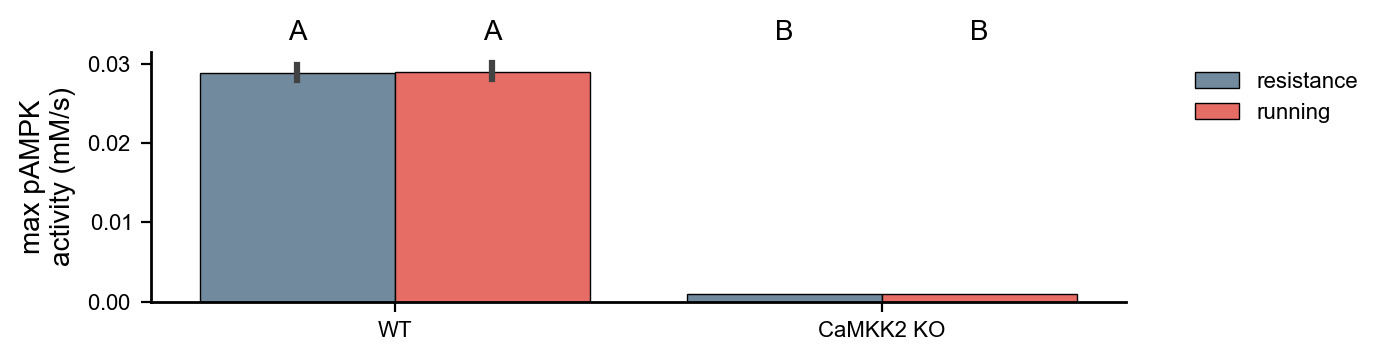

In [46]:
fig, ax = get_sized_fig_ax(3.25*width, height)
sns.barplot(data=df_long, ax=ax, x='condition', y='AMPK activity', hue='exercise',
            palette={'resistance': resist_color, 'running': run_color},
            linewidth=0.5, edgecolor='black')
ax.set_ylabel('max pAMPK\nactivity ' + r'(mM/s)', fontsize=10)
ax.legend(title='', fontsize=8, title_fontsize=8,
            loc='upper left', bbox_to_anchor=(1.05, 1), )
ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=8)

ylim = ax.get_ylim()
# Add CLD letters above each bar
for i, bar in enumerate(ax.patches):
    # Get the corresponding exercise and condition for each bar
    if i < 4:
        exercise = ax.get_legend_handles_labels()[1][i //2]
        condition = ax.get_xticklabels()[i %2].get_text()
        # Find the letter for this group
        letter_row = cld_df[(cld_df['exercise'] == exercise) & (cld_df['condition'] == condition)]
        if not letter_row.empty:
            letter = letter_row['Letters'].values[0]
            height_local = ylim[1] #bar.get_height()
            ax.annotate(letter, 
                        (bar.get_x() + bar.get_width() / 2, height_local), 
                        ha='center', va='bottom', fontsize=10, #fontweight='bold', 
                        xytext=(0, 2), textcoords='offset points')


fig.savefig(save_dir + 'exercise_AMPK_activity_barplot_kinase_KO.pdf', bbox_inches='tight',
            transparent=True)